# MLP FOR REGRESSION

## Plot the dataset

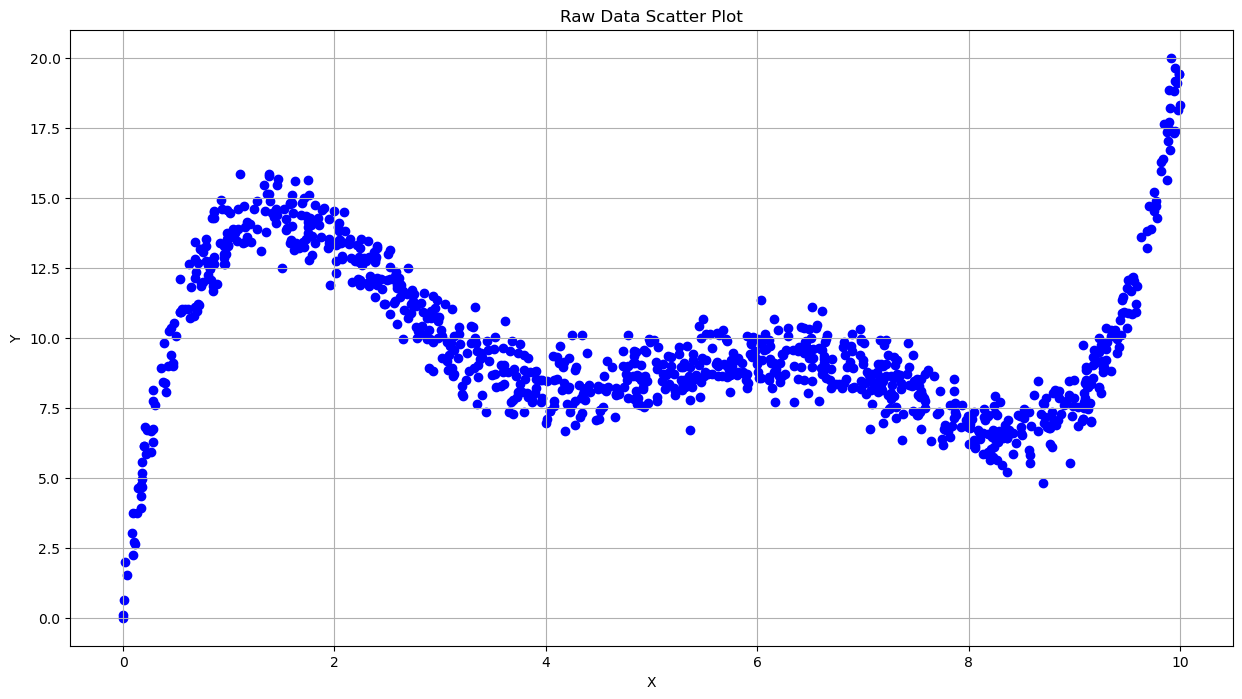

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('mlp_regression_data.csv')
X_train = df['x']
y_train = df['y']

plt.figure(figsize=(15, 8)) 
plt.scatter(X_train, y_train, marker='o', color='blue') 
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Raw Data Scatter Plot')
plt.grid(True) 
plt.show()

## Implement the model

In [125]:
import torch

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.all_layers = torch.nn.Sequential(
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),

            torch.nn.Linear(25, 25),
            torch.nn.ReLU(),

            torch.nn.Linear(25, 1)
        )

    def forward(self, x):
        logits = self.all_layers(x)
        return logits

## Data normalization

In [126]:
def normalize_data(X_train, y_train):
    X_mean, X_std = X_train.mean(), X_train.std()
    y_mean, y_std = y_train.mean(), y_train.std()

    X_train_norm = (X_train - X_mean) / X_std
    y_train_norm = (y_train - y_mean) / y_std

    return X_train_norm, y_train_norm, X_mean, X_std, y_mean, y_std

def unnormalize_data(y_norm, y_mean, y_std):
    return y_norm * y_std + y_mean

X_train_norm, y_train_norm, X_mean, X_std, y_mean, y_std = normalize_data(X_train, y_train)

## Dataloader

In [127]:
from torch.utils.data import Dataset, DataLoader
class RegressionDataset(Dataset):
    def __init__(self, X, Y):
        self.features = torch.tensor(X, dtype=torch.float32).reshape(-1, 1)
        self.labels = torch.tensor(Y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]
        y = self.labels[idx]
        return x, y
    
train_ds = RegressionDataset(X_train_norm, y_train_norm)
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=32,
    shuffle=True
)

## Training loop

In [129]:
import torch.nn.functional as F

model = MLP(num_features=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 700

train_losses = []


for epoch in range(num_epochs):
    model = model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = F.mse_loss(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_ds)

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.6f}")

Epoch 002 | Train Loss: 0.000897
Epoch 004 | Train Loss: 0.000818
Epoch 006 | Train Loss: 0.000747
Epoch 008 | Train Loss: 0.000669
Epoch 010 | Train Loss: 0.000578
Epoch 012 | Train Loss: 0.000491
Epoch 014 | Train Loss: 0.000404
Epoch 016 | Train Loss: 0.000333
Epoch 018 | Train Loss: 0.000272
Epoch 020 | Train Loss: 0.000226
Epoch 022 | Train Loss: 0.000175
Epoch 024 | Train Loss: 0.000156
Epoch 026 | Train Loss: 0.000136
Epoch 028 | Train Loss: 0.000127
Epoch 030 | Train Loss: 0.000111
Epoch 032 | Train Loss: 0.000106
Epoch 034 | Train Loss: 0.000095
Epoch 036 | Train Loss: 0.000095
Epoch 038 | Train Loss: 0.000085
Epoch 040 | Train Loss: 0.000088
Epoch 042 | Train Loss: 0.000084
Epoch 044 | Train Loss: 0.000084
Epoch 046 | Train Loss: 0.000082
Epoch 048 | Train Loss: 0.000090
Epoch 050 | Train Loss: 0.000078
Epoch 052 | Train Loss: 0.000078
Epoch 054 | Train Loss: 0.000078
Epoch 056 | Train Loss: 0.000079
Epoch 058 | Train Loss: 0.000077
Epoch 060 | Train Loss: 0.000078
Epoch 062 

## Plot regression curve

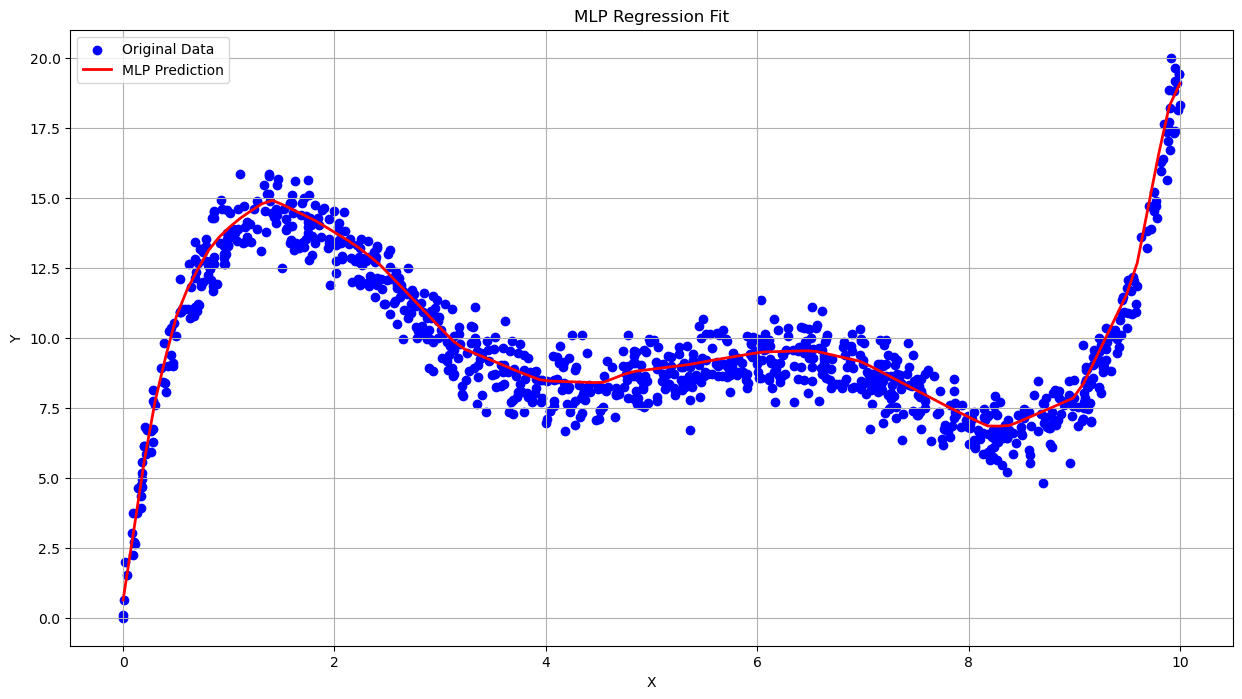

In [130]:
import numpy as np
import torch

model = model.eval()
with torch.no_grad():
    x_grid_orig = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)

    x_grid_norm = (x_grid_orig - X_mean) / X_std
    x_grid_tensor = torch.tensor(x_grid_norm, dtype=torch.float32).reshape(-1, 1)

    y_grid_pred_norm = model(x_grid_tensor).numpy()
    y_grid_pred_orig = unnormalize_data(y_grid_pred_norm, y_mean, y_std)

plt.figure(figsize=(15, 8))
plt.scatter(X_train, y_train, marker='o', color='blue', label='Original Data')
plt.plot(x_grid_orig, y_grid_pred_orig, color='red', linewidth=2, label='MLP Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('MLP Regression Fit')
plt.legend()
plt.grid(True)
plt.show()
    

## Plot training loss

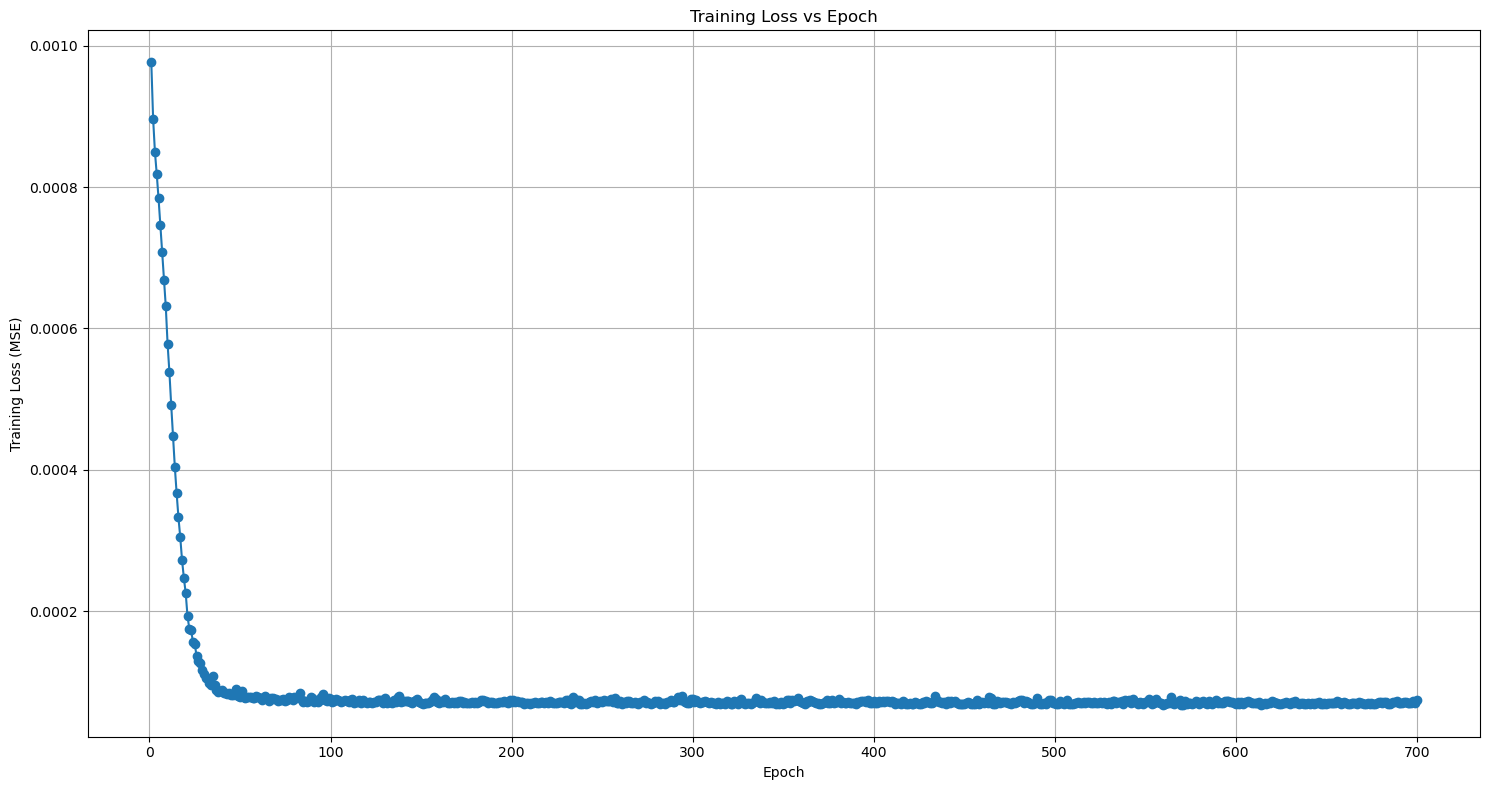

In [131]:
plt.figure(figsize=(15,8))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss vs Epoch')
plt.grid(True)
plt.tight_layout()
plt.show()